In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mne 
import numpy as np
import pickle
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter

from mne.stats import spatio_temporal_cluster_test, f_mway_rm, f_threshold_mway_rm, permutation_t_test
from statsmodels.stats.multitest import multipletests
from scipy.ndimage import gaussian_filter

In [2]:
plt.rcParams.update({
        'font.size': 16,
        'axes.spines.right': False,
        'axes.spines.top': False,
        'xtick.major.size': 6,
        'xtick.major.width': 1.2,
        'ytick.major.size': 6,
        'ytick.major.width': 1.2,
        'legend.frameon': False,
        'legend.handletextpad': 0.1,
        'svg.fonttype': 'none',
        'text.usetex': False
    })

In [3]:
output_dir = '/home/qmoreau/schmidt_data/output'

bursts_all_results_laplac = np.load(f'{output_dir}/bursts_all_results_laplac.npy', allow_pickle=True)

In [4]:
all_bursts={
    'trial': [],
    'waveform': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
    'waveform_times': [],
    'condition': [],
    'electrode': [],
    'subject': [],
    'experiment': [],
    'epochs': []
}
for bursts in bursts_all_results_laplac:
    for key in bursts:
        if not key=='waveform_times':
            all_bursts[key].extend(bursts[key])
        else:
            all_bursts[key]=bursts[key]
            
for key in all_bursts:
    all_bursts[key]=np.array(all_bursts[key])

In [5]:
c3_idx=(all_bursts['electrode']=='C3')
f4_idx=(all_bursts['electrode']=='F4')

In [6]:
waveforms_laplac_C3=all_bursts['waveform'][c3_idx,:]

# Scaling and PCA on the entire dataset
model_laplac_C3 = PCA(n_components=20)
scaler_laplac_C3 = RobustScaler().fit(waveforms_laplac_C3)
waveforms_laplac_C3_std = scaler_laplac_C3.transform(waveforms_laplac_C3)
model_laplac_C3.fit(waveforms_laplac_C3_std)

cum_var_exp=np.cumsum(model_laplac_C3.explained_variance_ratio_)
if len(np.where(cum_var_exp>=.8)[0]):
    idx=np.min(np.where(cum_var_exp>=.8)[0])
else:
    idx=len(cum_var_exp)-1
print('{} components explain {}% of variance'.format(idx+1,cum_var_exp[idx]*100))

# Transforming the data to get principal components
pc_scores_laplac_C3 = model_laplac_C3.transform(waveforms_laplac_C3_std)  # all the bursts x 20 components
pc_labels_laplac_C3 = ["PC_{}".format(i + 1) for i in range(pc_scores_laplac_C3.shape[1])]

8 components explain 80.206891001343% of variance


In [7]:
waveforms_laplac_F4=all_bursts['waveform'][f4_idx,:]

# Scaling and PCA on the entire dataset
model_laplac_F4 = PCA(n_components=20)
scaler_laplac_F4 = RobustScaler().fit(waveforms_laplac_F4)
waveforms_laplac_F4_std = scaler_laplac_F4.transform(waveforms_laplac_F4)
model_laplac_F4.fit(waveforms_laplac_F4_std)

cum_var_exp=np.cumsum(model_laplac_F4.explained_variance_ratio_)
if len(np.where(cum_var_exp>=.8)[0]):
    idx=np.min(np.where(cum_var_exp>=.8)[0])
else:
    idx=len(cum_var_exp)-1
print('{} components explain {}% of variance'.format(idx+1,cum_var_exp[idx]*100))

# Transforming the data to get principal components
pc_scores_laplac_F4 = model_laplac_F4.transform(waveforms_laplac_F4_std)  # all the bursts x 20 components
pc_labels_laplac_F4 = ["PC_{}".format(i + 1) for i in range(pc_scores_laplac_F4.shape[1])]

11 components explain 80.72007970367741% of variance


In [8]:
all_burst_pc_scores=np.zeros((all_bursts['waveform'].shape[0],20))
all_burst_pc_scores[c3_idx,:]=pc_scores_laplac_C3
all_burst_pc_scores[f4_idx,:]=pc_scores_laplac_F4

In [9]:
# Save the fitted scaler and PCA objects
with open('robust_scaler_c3.pkl', 'wb') as scaler_file:
    pickle.dump(scaler_laplac_C3, scaler_file)

with open('pca_object_c3.pkl', 'wb') as pca_file:
    pickle.dump(model_laplac_C3, pca_file)
    
with open('robust_scaler_f4.pkl', 'wb') as scaler_file:
    pickle.dump(scaler_laplac_F4, scaler_file)

with open('pca_object_f4.pkl', 'wb') as pca_file:
    pickle.dump(model_laplac_F4, pca_file)

In [10]:
def shuffle_array(array):
    X_array = array.copy()
    rows, columns = array.shape
    for col in range(columns):
        ixes = np.arange(0,rows)
        np.random.shuffle(ixes)
        X_array[:,col] = X_array[:,col][ixes]
    return X_array

def shuffle_array_range(array, ranges):
    X_array = []
    for x1, x2 in ranges:
        X = wvf[:,x1:x2]
        np.random.shuffle(X)
        X_array.append(X)
    return np.hstack(X_array)

def get_num_components(waveforms, n_comps):
    # robust scaling
    waveforms_scaled = RobustScaler().fit_transform(waveforms)

    # main PCA fitting
    pca_full = PCA(n_components=n_comps)
    pcs_full = pca_full.fit_transform(waveforms_scaled)
    var_full = pca_full.explained_variance_ratio_ 

    # robustness of pca components
    no_of_iter = 100
    pca_vars = []
    for i in range(no_of_iter):
        shuffled_wvf = shuffle_array(waveforms_scaled)

        pca_shuff = PCA(n_components=n_comps)
        pca_shuff.fit(shuffled_wvf)
        pca_vars.append(pca_shuff.explained_variance_ratio_)        
    del shuffled_wvf
    pca_vars=np.array(pca_vars)

    # getting the magic number
    results = np.sum(var_full>pca_vars, axis=0) / no_of_iter
    threshold=1-(.05/n_comps)
    PCS_to_analyse = np.where(results > threshold)[0]
    return PCS_to_analyse

In [11]:
c3_shuffling_results=get_num_components(all_bursts['waveform'][c3_idx,:], 20)
print(f'C3 non-noise PCs: {c3_shuffling_results}')

f4_shuffling_results=get_num_components(all_bursts['waveform'][f4_idx,:], 20)
print(f'F4 non-noise PCs: {f4_shuffling_results}')

C3 non-noise PCs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
F4 non-noise PCs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


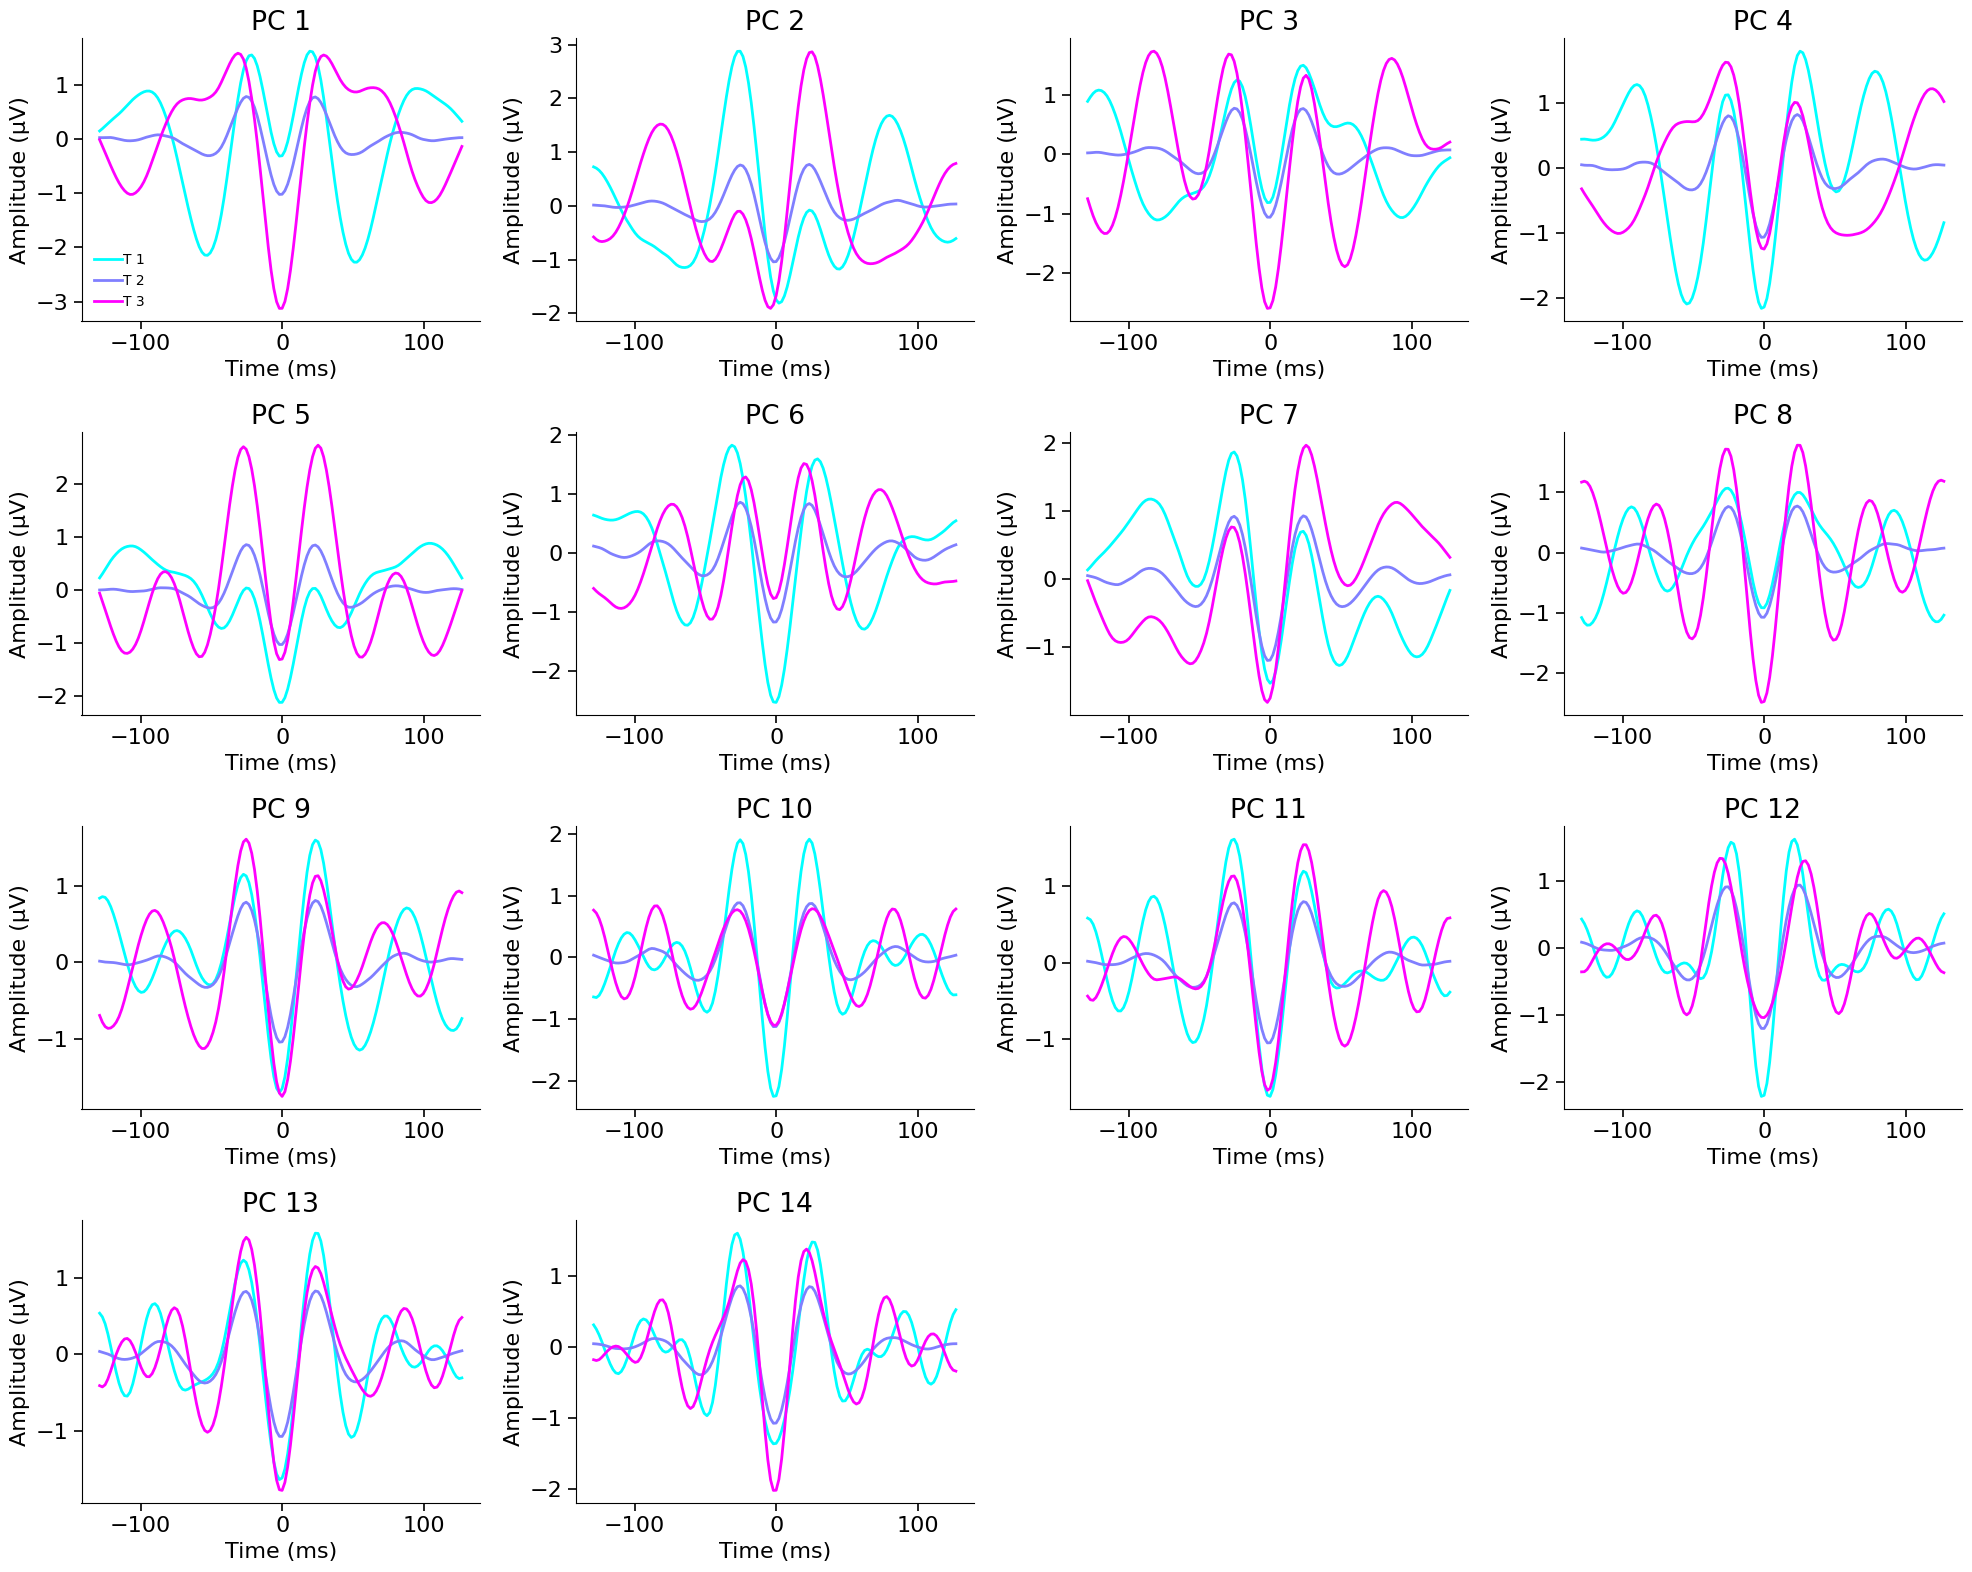

In [12]:
# Tertile calculation
quartiles_laplac_C3 = np.linspace(0, 100, num=4)
quartiles_laplac_C3 = list(zip(quartiles_laplac_C3[:-1], quartiles_laplac_C3[1:]))
col_range_laplac_C3 = plt.cm.cool(np.linspace(0, 1, num=len(quartiles_laplac_C3)))
mean_waveform_laplac_C3 = np.mean(waveforms_laplac_C3, axis=0)

# Plotting the PCA results
f_laplac_C3=plt.figure(figsize=(20, 16))
ax_idx=0
for pc_ix, pc in enumerate(c3_shuffling_results):
    ax_laplac_C3=plt.subplot(4,4,ax_idx+1)
    ax_laplac_C3.set_title(f'PC {pc+1}')  # Set the nice title
    scores_laplac_C3 = pc_scores_laplac_C3[:,pc_ix]  # Select the appropriate principal component from the dataframe
    q_maps_laplac_C3 = []
    for q_ix, (b, e) in enumerate(quartiles_laplac_C3):
        q_map_laplac_C3 = (scores_laplac_C3 > np.percentile(scores_laplac_C3, b)) & (scores_laplac_C3 <= np.percentile(scores_laplac_C3, e))  # Create a boolean map to select the waveforms_laplac_C3
        q_mean_laplac_C3 = np.mean(waveforms_laplac_C3[q_map_laplac_C3], axis=0)
        ax_laplac_C3.plot(all_bursts['waveform_times'][:132]*1e3, q_mean_laplac_C3*1e3, lw=2, c=col_range_laplac_C3[q_ix], label="T {}".format(q_ix + 1))
    #ax_laplac_C3.plot(all_bursts['waveform_times'][:132]*1e3, mean_waveform_laplac_C3*1e3, lw=2, c="black", label="mean")
    if ax_idx==0:
        ax_laplac_C3.legend(fontsize=10)
    ax_laplac_C3.set_xlabel('Time (ms)')
    ax_laplac_C3.set_ylabel('Amplitude (µV)')
    ax_idx=ax_idx+1
plt.tight_layout()
# plt.savefig('./figures/figure_xx_C3_PCA.pdf')

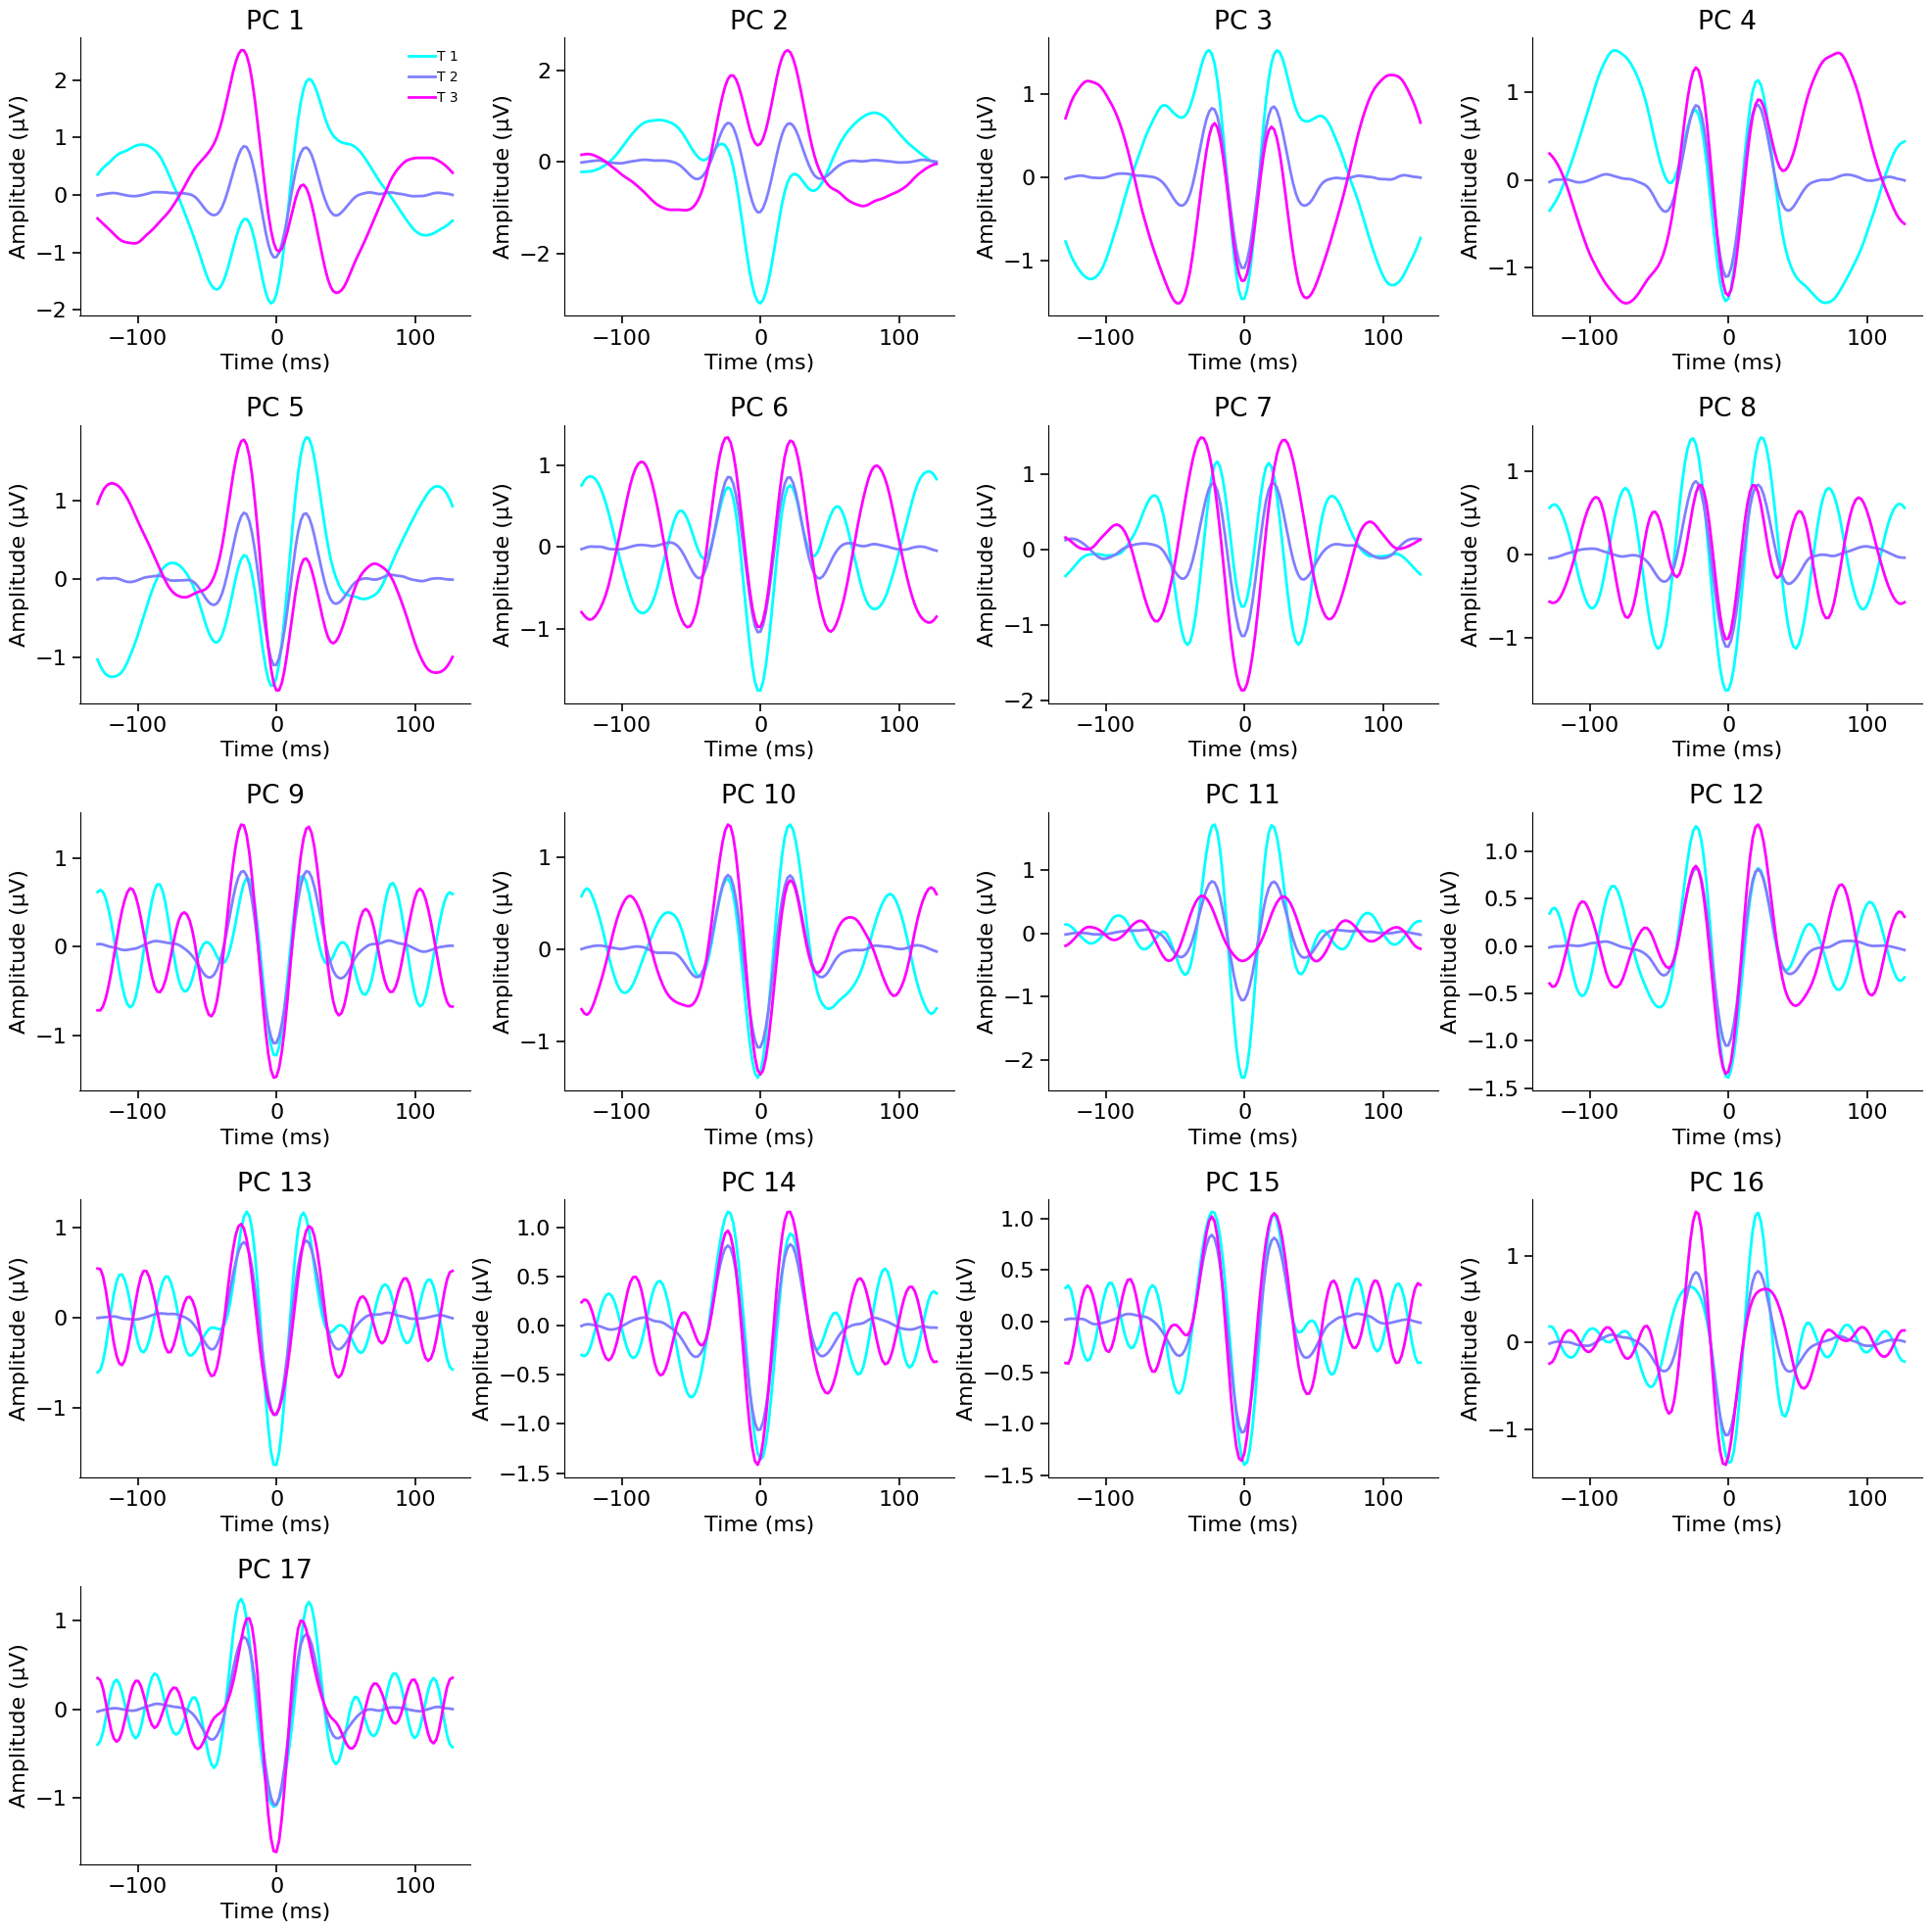

In [13]:
# Tertile calculation
quartiles_laplac_F4 = np.linspace(0, 100, num=4)
quartiles_laplac_F4 = list(zip(quartiles_laplac_F4[:-1], quartiles_laplac_F4[1:]))
col_range_laplac_F4 = plt.cm.cool(np.linspace(0, 1, num=len(quartiles_laplac_F4)))
mean_waveform_laplac_F4 = np.mean(waveforms_laplac_F4, axis=0)

# Plotting the PCA results
f_laplac_F4=plt.figure(figsize=(20, 20))
ax_idx=0
for pc_ix, pc in enumerate(f4_shuffling_results):
    ax_laplac_F4=plt.subplot(5,4,ax_idx+1)
    ax_laplac_F4.set_title(f'PC {pc+1}')  # Set the nice title
    scores_laplac_F4 = pc_scores_laplac_F4[:,pc_ix]  # Select the appropriate principal component from the dataframe
    q_maps_laplac_F4 = []
    for q_ix, (b, e) in enumerate(quartiles_laplac_F4):
        q_map_laplac_F4 = (scores_laplac_F4 > np.percentile(scores_laplac_F4, b)) & (scores_laplac_F4 <= np.percentile(scores_laplac_F4, e))
        q_mean_laplac_F4 = np.mean(waveforms_laplac_F4[q_map_laplac_F4], axis=0)
        ax_laplac_F4.plot(all_bursts['waveform_times'][:132]*1e3, q_mean_laplac_F4*1e3, lw=2, c=col_range_laplac_F4[q_ix], label="T {}".format(q_ix + 1))
#     ax_laplac_F4.plot(all_bursts['waveform_times']*1e3, mean_waveform_laplac_F4*1e3, lw=2, c="black", label="mean")
    if ax_idx==0:
        ax_laplac_F4.legend(fontsize=10)
    ax_laplac_F4.set_xlabel('Time (ms)')
    ax_laplac_F4.set_ylabel('Amplitude (µV)')
    ax_idx=ax_idx+1
plt.tight_layout()
#plt.savefig('./figures/figure_xx_F4_PCA.pdf')

In [14]:
def score_var_permutation_test(pcs, b_idx):
    smth_krnl = 2.5
    n_permutations = 10000
    time_bins = np.arange(-0.25, 2, 0.02)
    bin_centers = 0.5 * (time_bins[:-1] + time_bins[1:])
    n_bins = len(time_bins) - 1
    subjects = np.unique(all_bursts['subject'])

    def safe_digitize(times, bins):
        idx = np.digitize(times, bins=bins) - 1
        idx[idx < 0] = 0
        idx[idx >= n_bins] = n_bins - 1
        return idx

    subject_data = {}
    for subject in subjects:
        subj_mask = (all_bursts['subject'] == subject) & b_idx
        ss_mask = subj_mask & (all_bursts['condition'] == 'SS')
        fs_mask = subj_mask & (all_bursts['condition'] == 'FS')
        if not np.any(ss_mask) or not np.any(fs_mask):
            continue

        ss_times = all_bursts['peak_time'][ss_mask]
        ss_scores = all_burst_pc_scores[ss_mask, :]
        ss_bin_idx = safe_digitize(ss_times, time_bins)

        fs_times = all_bursts['peak_time'][fs_mask]
        fs_scores = all_burst_pc_scores[fs_mask, :]
        fs_bin_idx = safe_digitize(fs_times, time_bins)

        subject_data[subject] = {
            'ss_bin_idx': ss_bin_idx,
            'ss_scores': ss_scores,
            'fs_bin_idx': fs_bin_idx,
            'fs_scores': fs_scores
        }

    observed_mean_diff = {}
    pc_means_over_time = {'SS': {}, 'FS': {}}
    subject_bin_means_diff = {}  # To store subject-level differences for paired testing

    for pc in pcs:
        subject_bin_means = {'SS': [], 'FS': []}
        subject_bin_means_diff[pc] = []
        
        for subject in subject_data:
            ss_bin_idx = subject_data[subject]['ss_bin_idx']
            ss_scores = subject_data[subject]['ss_scores'][:, pc]
            ss_bin_sum = np.bincount(ss_bin_idx, weights=ss_scores, minlength=n_bins)
            ss_bin_count = np.bincount(ss_bin_idx, minlength=n_bins)
            ss_subj_means = np.divide(ss_bin_sum, ss_bin_count, out=np.zeros(n_bins), where=(ss_bin_count > 0))
            ss_subj_means = gaussian_filter(ss_subj_means, sigma=smth_krnl)
            subject_bin_means['SS'].append(ss_subj_means)

            fs_bin_idx = subject_data[subject]['fs_bin_idx']
            fs_scores = subject_data[subject]['fs_scores'][:, pc]
            fs_bin_sum = np.bincount(fs_bin_idx, weights=fs_scores, minlength=n_bins)
            fs_bin_count = np.bincount(fs_bin_idx, minlength=n_bins)
            fs_subj_means = np.divide(fs_bin_sum, fs_bin_count, out=np.zeros(n_bins), where=(fs_bin_count > 0))
            fs_subj_means = gaussian_filter(fs_subj_means, sigma=smth_krnl)
            subject_bin_means['FS'].append(fs_subj_means)
            
            # Calculate difference between conditions for this subject
            subj_diff = ss_subj_means - fs_subj_means
            subject_bin_means_diff[pc].append(subj_diff)

        subject_bin_means['SS'] = np.array(subject_bin_means['SS'])
        subject_bin_means['FS'] = np.array(subject_bin_means['FS'])
        subject_bin_means_diff[pc] = np.array(subject_bin_means_diff[pc])
        
        ss_mean_over_subs = np.mean(subject_bin_means['SS'], axis=0)
        fs_mean_over_subs = np.mean(subject_bin_means['FS'], axis=0)
        pc_means_over_time['SS'][pc] = ss_mean_over_subs
        pc_means_over_time['FS'][pc] = fs_mean_over_subs

        # Observed mean difference is now based on the mean of subject-level differences
        observed_mean_diff[pc] = np.sum(np.abs(np.mean(subject_bin_means_diff[pc], axis=0)))

    null_mean_diffs = {pc: [] for pc in pcs}

    for _ in range(n_permutations):
        for pc in pcs:
            # For paired test, we randomly flip the sign of the difference for each subject
            permuted_diffs = []
            
            for subj_idx, subject_diff in enumerate(subject_bin_means_diff[pc]):
                # Randomly decide whether to flip the sign for this subject
                if np.random.rand() < 0.5:
                    permuted_diffs.append(-subject_diff)  # Flip the sign
                else:
                    permuted_diffs.append(subject_diff)   # Keep original sign
            
            permuted_diffs = np.array(permuted_diffs)
            mean_permuted_diff = np.mean(permuted_diffs, axis=0)
            null_mean_diffs[pc].append(np.sum(np.abs(mean_permuted_diff)))

    p_vals = {pc: (np.sum(np.array(null_mean_diffs[pc]) >= observed_mean_diff[pc]) + 1) / (n_permutations + 1) for pc in observed_mean_diff}
    significant_pcs = [pc for pc in pcs if p_vals[pc] < 0.05]

    print(f"Significant PCs: {significant_pcs}")
    
    # Optional: Print p-values for each PC
    for pc in pcs:
        print(f"PC {pc+1}: p-value = {p_vals[pc]:.4f}" + (" *" if pc in significant_pcs else ""))

    num_pcs = len(pcs)
    num_rows = int(np.ceil(num_pcs / 4))
    fig, axs = plt.subplots(num_rows, 4, figsize=(20, 5 * num_rows))
    axs = axs.flatten()

    for i, pc in enumerate(pcs):
        ax = axs[i]
        ss_bin_means = pc_means_over_time['SS'][pc]
        fs_bin_means = pc_means_over_time['FS'][pc]

        ax.plot(bin_centers, ss_bin_means, label='SS')
        ax.plot(bin_centers, fs_bin_means, label='FS')
        ax.legend()
        ax.set_xlim(bin_centers[0], bin_centers[-1])
        color = 'red' if pc in significant_pcs else 'black'
        ax.set_title(f"PC {pc + 1}" + (" *" if pc in significant_pcs else ""), color=color)

        if i % 4 == 0:
            ax.set_ylabel("Mean Score")
        if i >= (num_pcs - 4):
            ax.set_xlabel("Time (s)")

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

    return observed_mean_diff, null_mean_diffs, significant_pcs

Significant PCs: [2, 11]
PC 1: p-value = 0.1199
PC 2: p-value = 0.5971
PC 3: p-value = 0.0127 *
PC 4: p-value = 0.4629
PC 5: p-value = 0.1300
PC 6: p-value = 0.4783
PC 7: p-value = 0.8194
PC 8: p-value = 0.0607
PC 9: p-value = 0.4445
PC 10: p-value = 0.5338
PC 11: p-value = 0.0732
PC 12: p-value = 0.0065 *
PC 13: p-value = 0.6871
PC 14: p-value = 0.4776


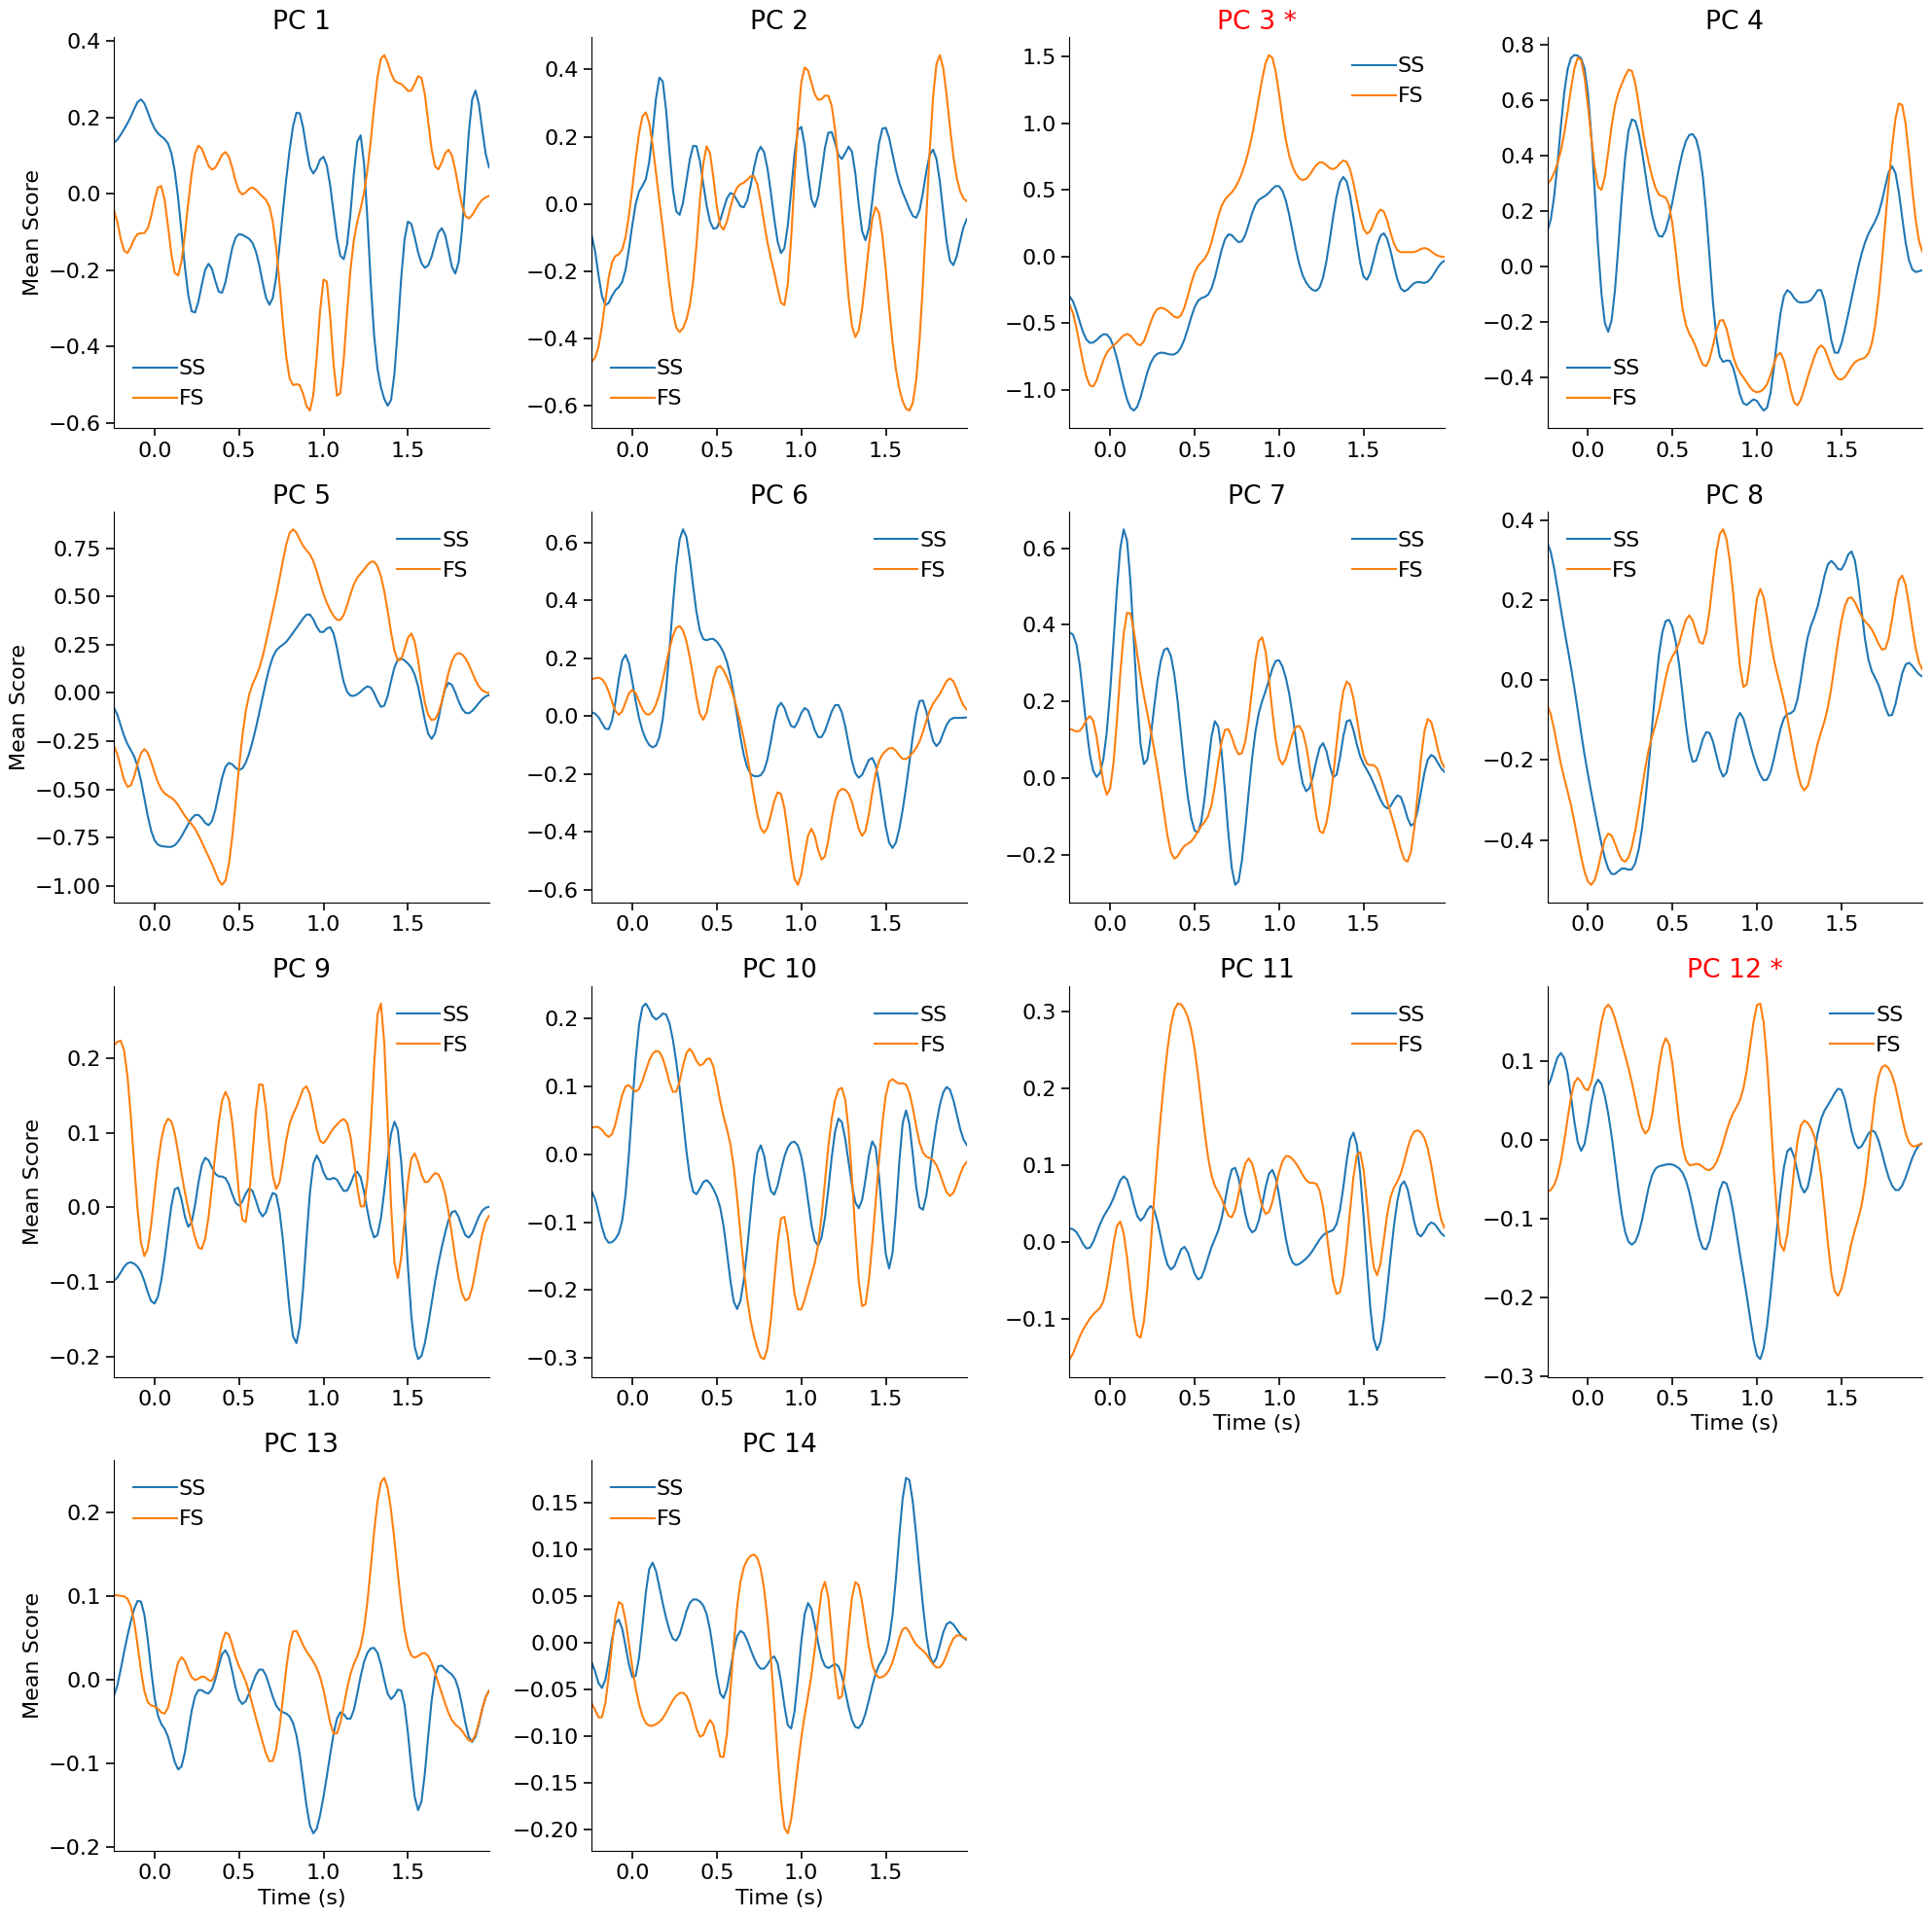

In [15]:
observed_mean_diff_c3, null_mean_diffs_c3, significant_pcs_c3 = score_var_permutation_test(c3_shuffling_results, c3_idx)

In [16]:
# significant_pcs_c3=significant_pcs_c3[:-1]

Significant PCs: [5, 10]
PC 1: p-value = 0.0909
PC 2: p-value = 0.4565
PC 3: p-value = 0.8782
PC 4: p-value = 0.4942
PC 5: p-value = 0.7045
PC 6: p-value = 0.0041 *
PC 7: p-value = 0.5178
PC 8: p-value = 0.2672
PC 9: p-value = 0.5448
PC 10: p-value = 0.4431
PC 11: p-value = 0.0469 *
PC 12: p-value = 0.8495
PC 13: p-value = 0.5242
PC 14: p-value = 0.4082
PC 15: p-value = 0.9095
PC 16: p-value = 0.7186
PC 17: p-value = 0.6930


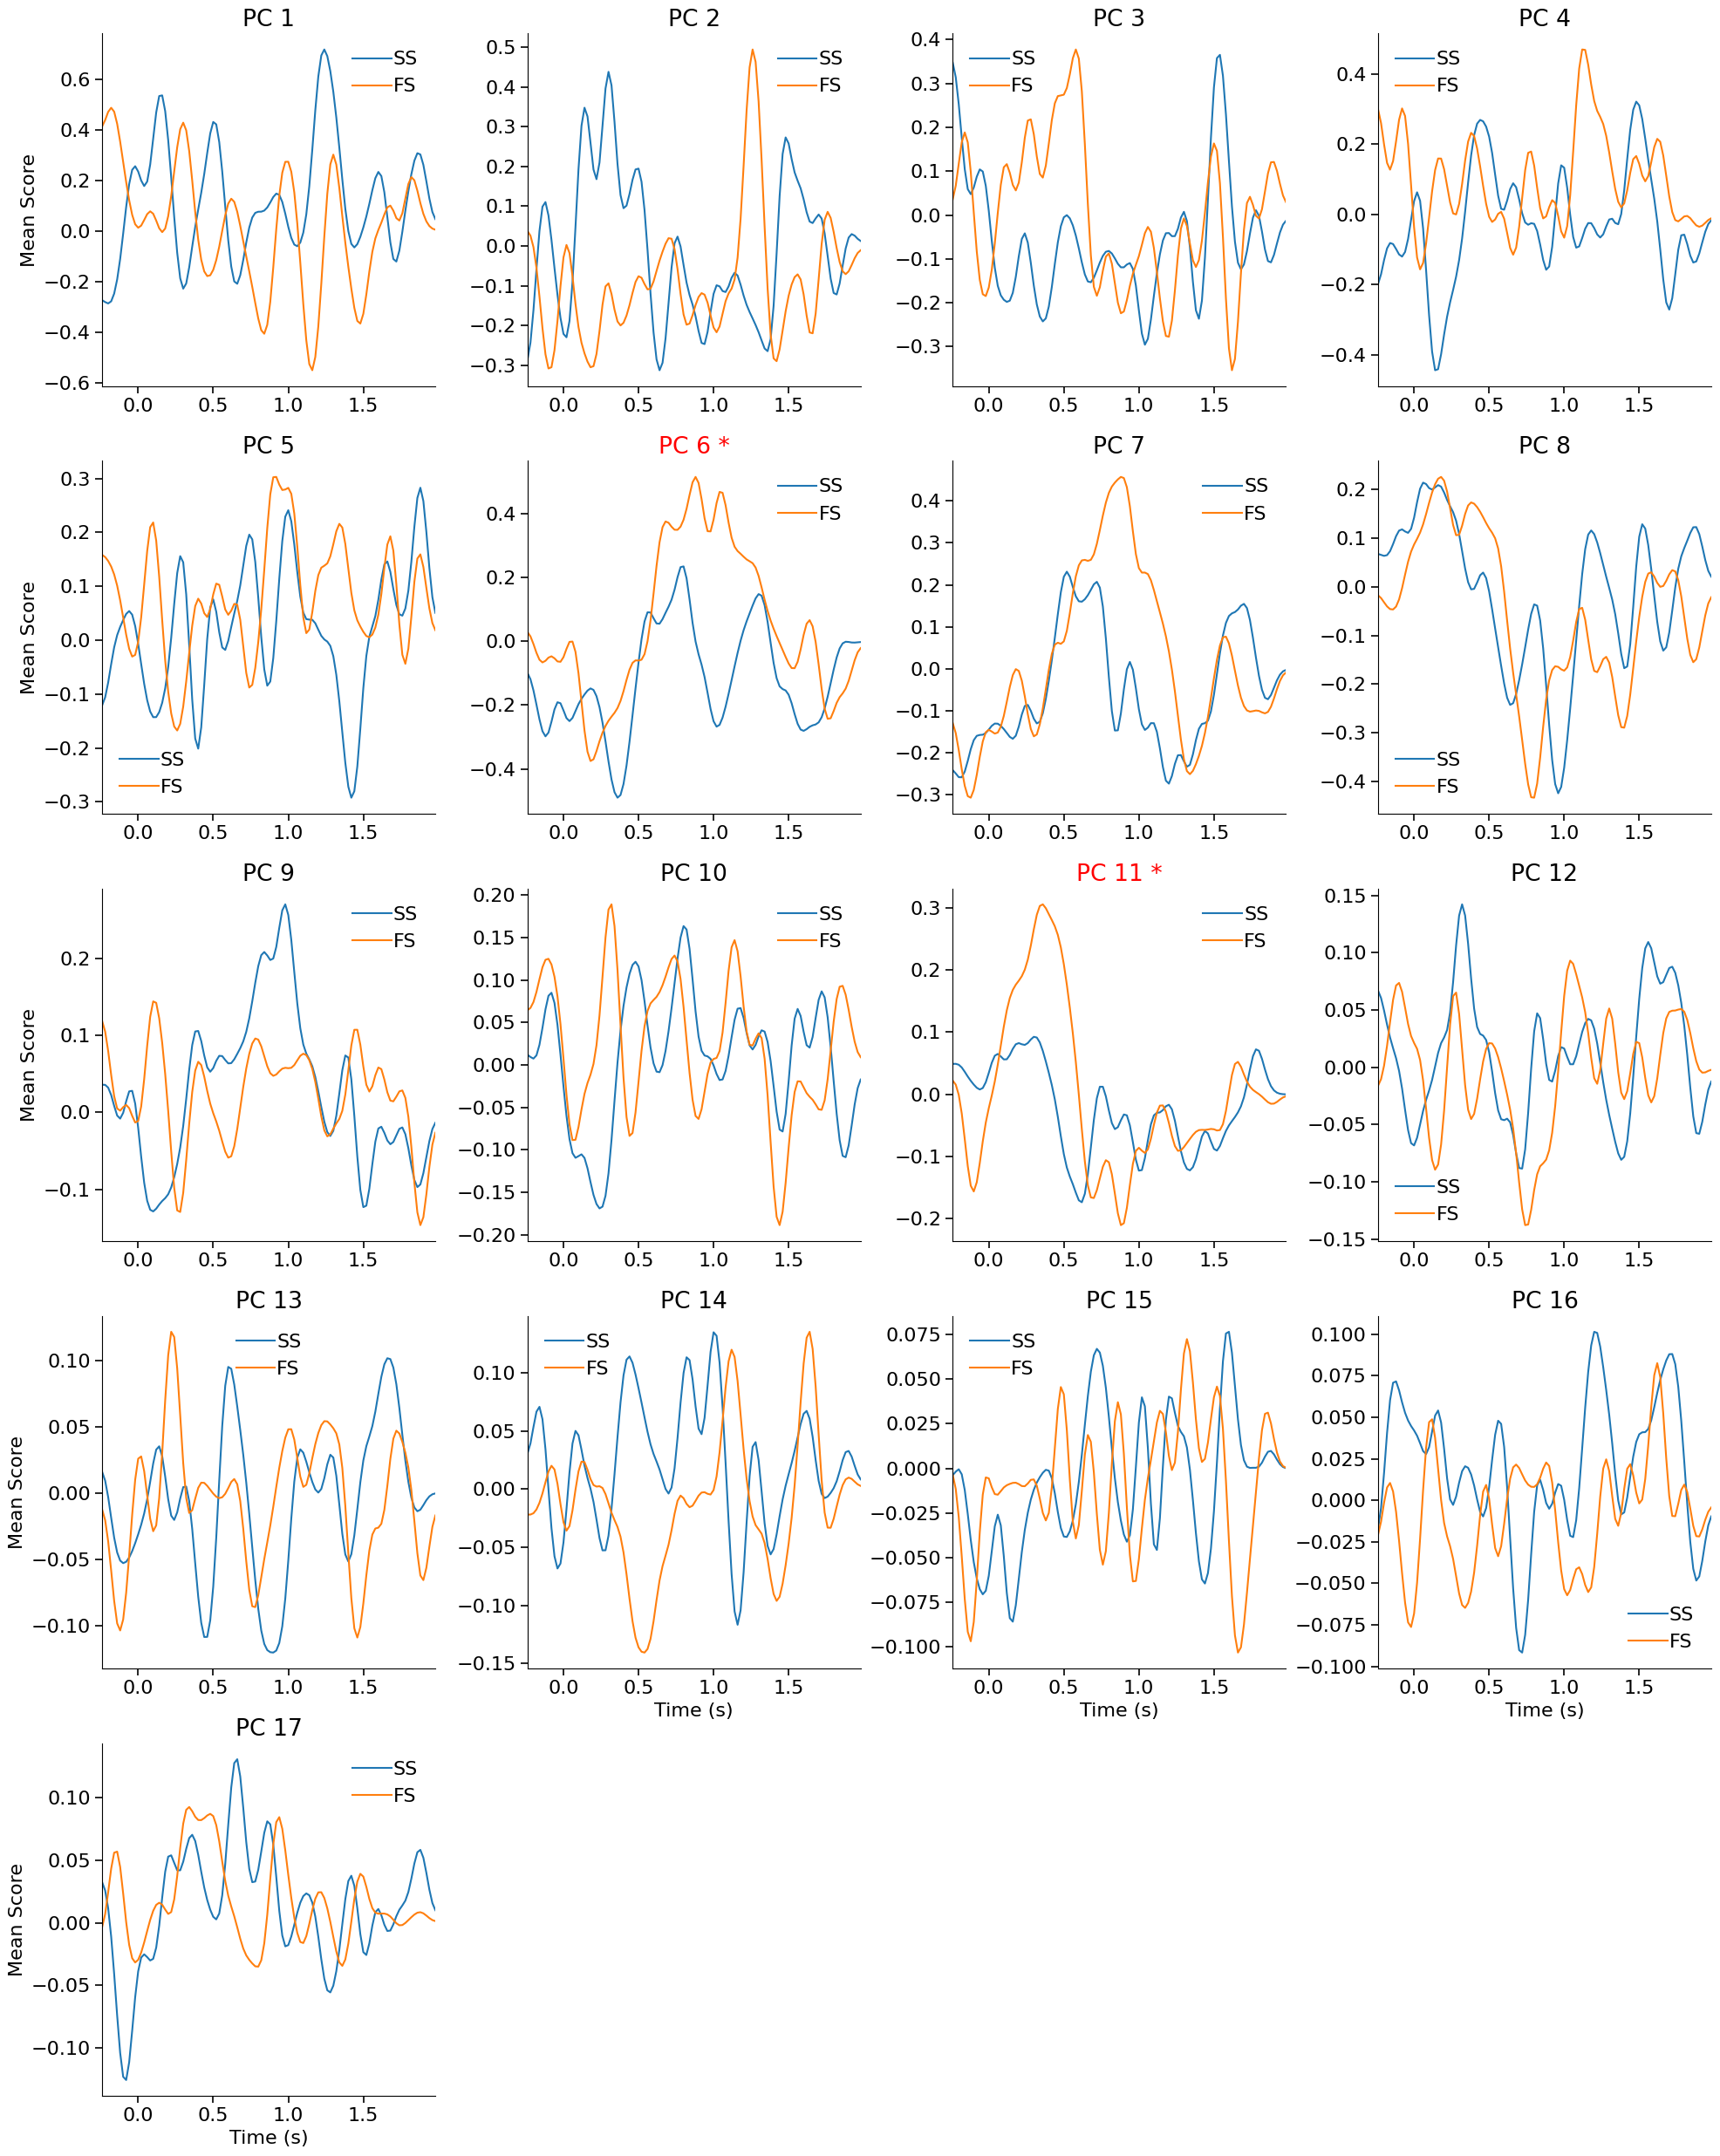

In [17]:
observed_mean_diff_f4, null_mean_diffs_f4, significant_pcs_f4 = score_var_permutation_test(f4_shuffling_results, f4_idx)

/tmp/ipykernel_57726/2077359477.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap("turbo_r")
/tmp/ipykernel_57726/2077359477.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap("turbo_r")


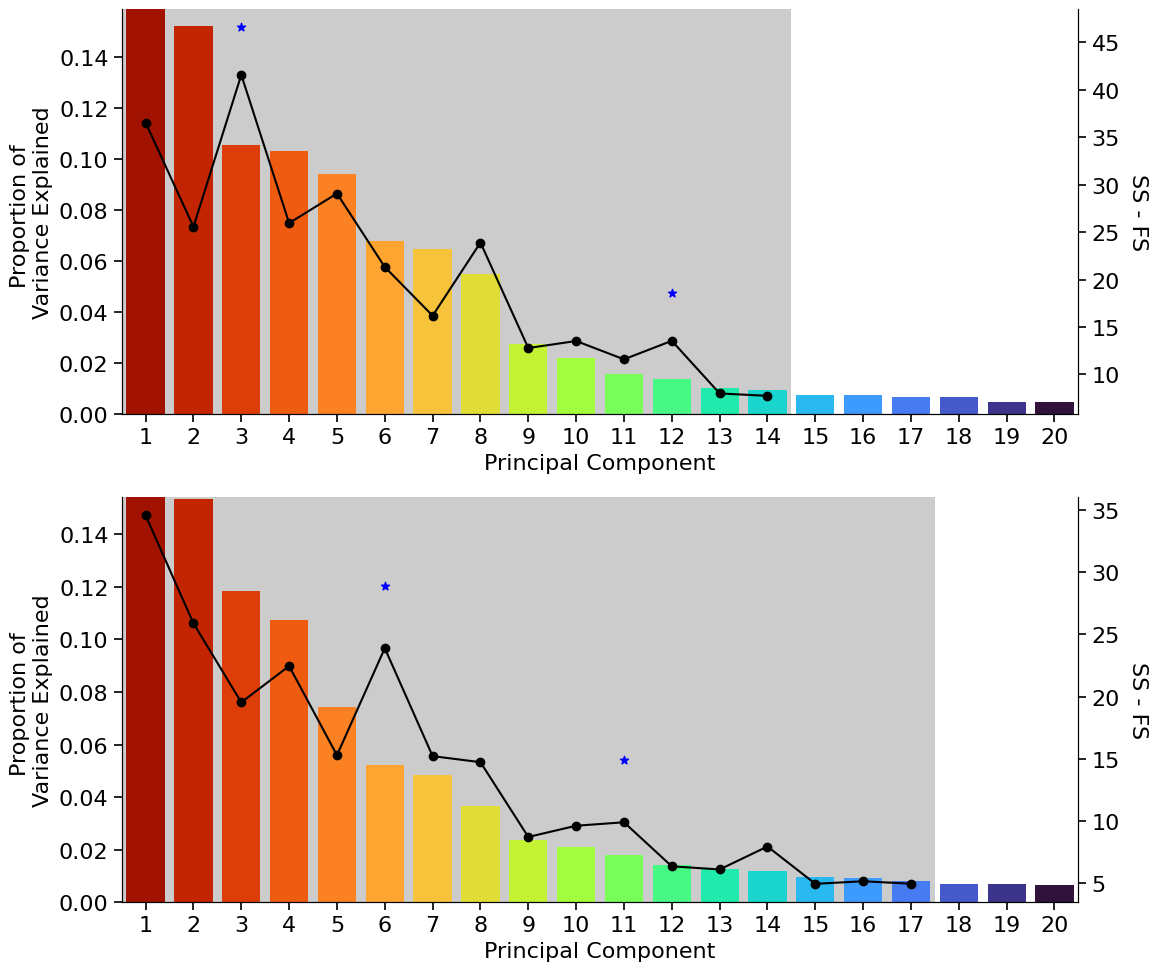

In [18]:
plt.rcParams.update({
    'axes.spines.right': True
})
fig = plt.figure(figsize=(12,10))
ax = plt.subplot(2, 1, 1)
PC_var_exp = model_laplac_C3.explained_variance_ratio_
PC_r = np.arange(PC_var_exp.shape[0]) + 1
shuf_plot=np.zeros(PC_var_exp.shape[0])
shuf_plot[c3_shuffling_results]=np.max(PC_var_exp)
bar = ax.bar(PC_r, shuf_plot, lw=0.2, color="black", alpha=0.2, width=1)
bar = ax.bar(PC_r, PC_var_exp, lw=0.2)
cm = plt.cm.get_cmap("turbo_r")
for i in PC_r:
    plt.setp(bar[i-1],"facecolor", cm(i/20))
ax.set_xlabel("Principal Component")
ax.set_ylabel("Proportion of \nVariance Explained")
ax.set_ylim([0, PC_var_exp[0]])
ax.set_xticks(PC_r)
ax.set_xlim(0.5, PC_r[-1] + 0.5)
ax2 = ax.twinx()
ax2.scatter(c3_shuffling_results+1, [observed_mean_diff_c3[x] for x in c3_shuffling_results], color='k')
ax2.plot(c3_shuffling_results+1, [observed_mean_diff_c3[x] for x in c3_shuffling_results], color='k')
ax2.scatter(np.array(significant_pcs_c3)+1, [observed_mean_diff_c3[x]+5 for x in significant_pcs_c3],marker='*',color='b')
ax2.set_ylabel("SS - FS", rotation=-90, labelpad=20)

ax = plt.subplot(2, 1, 2)
PC_var_exp = model_laplac_F4.explained_variance_ratio_
PC_r = np.arange(PC_var_exp.shape[0]) + 1
shuf_plot=np.zeros(PC_var_exp.shape[0])
shuf_plot[f4_shuffling_results]=np.max(PC_var_exp)
bar = ax.bar(PC_r, shuf_plot, lw=0.2, color="black", alpha=0.2, width=1)
bar = ax.bar(PC_r, PC_var_exp, lw=0.2)
cm = plt.cm.get_cmap("turbo_r")
for i in PC_r:
    plt.setp(bar[i-1],"facecolor", cm(i/20))
ax.set_xlabel("Principal Component")
ax.set_ylabel("Proportion of \nVariance Explained")
ax.set_ylim([0, PC_var_exp[0]])
ax.set_xticks(PC_r)
ax.set_xlim(0.5, PC_r[-1] + 0.5)
ax2 = ax.twinx()
ax2.scatter(f4_shuffling_results+1, [observed_mean_diff_f4[x] for x in f4_shuffling_results], color='k')
ax2.plot(f4_shuffling_results+1, [observed_mean_diff_f4[x] for x in f4_shuffling_results], color='k')
ax2.scatter(np.array(significant_pcs_f4)+1, [observed_mean_diff_f4[x]+5 for x in significant_pcs_f4],marker='*',color='b')
ax2.set_ylabel("SS - FS", rotation=-90, labelpad=20)

plt.tight_layout()
plt.rcParams.update({
    'axes.spines.right': True
})
#plt.savefig('./figures/figure_xx_PCA_var_explained.pdf')

/tmp/ipykernel_57726/3293385447.py:98: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  _, clusters, cluster_p_values, _ = permutation_cluster_1samp_test(
/tmp/ipykernel_57726/3293385447.py:98: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  _, clusters, cluster_p_values, _ = permutation_cluster_1samp_test(


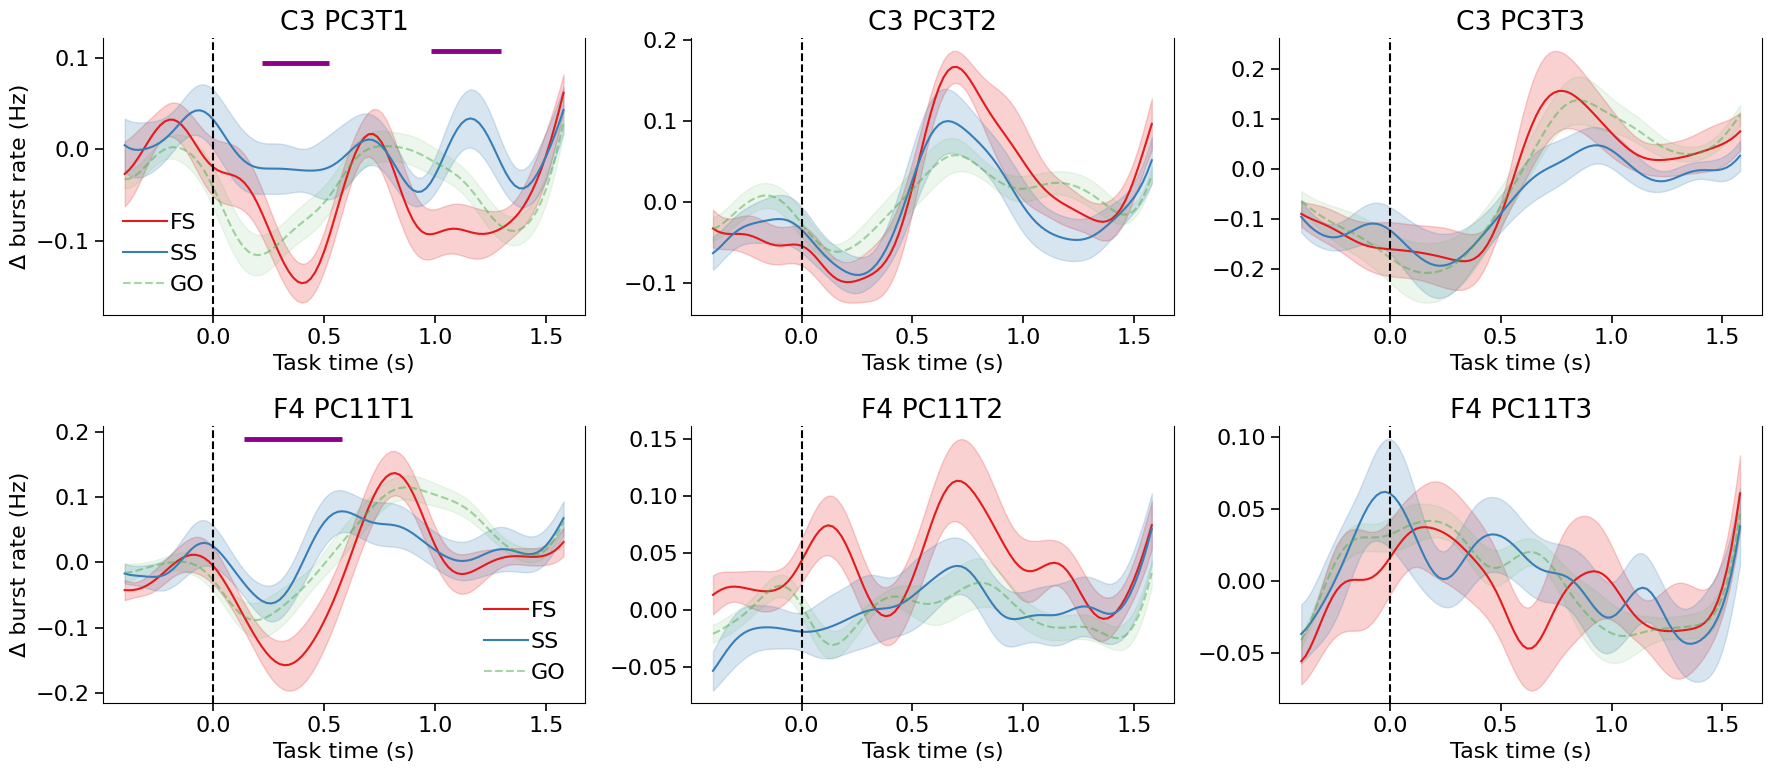

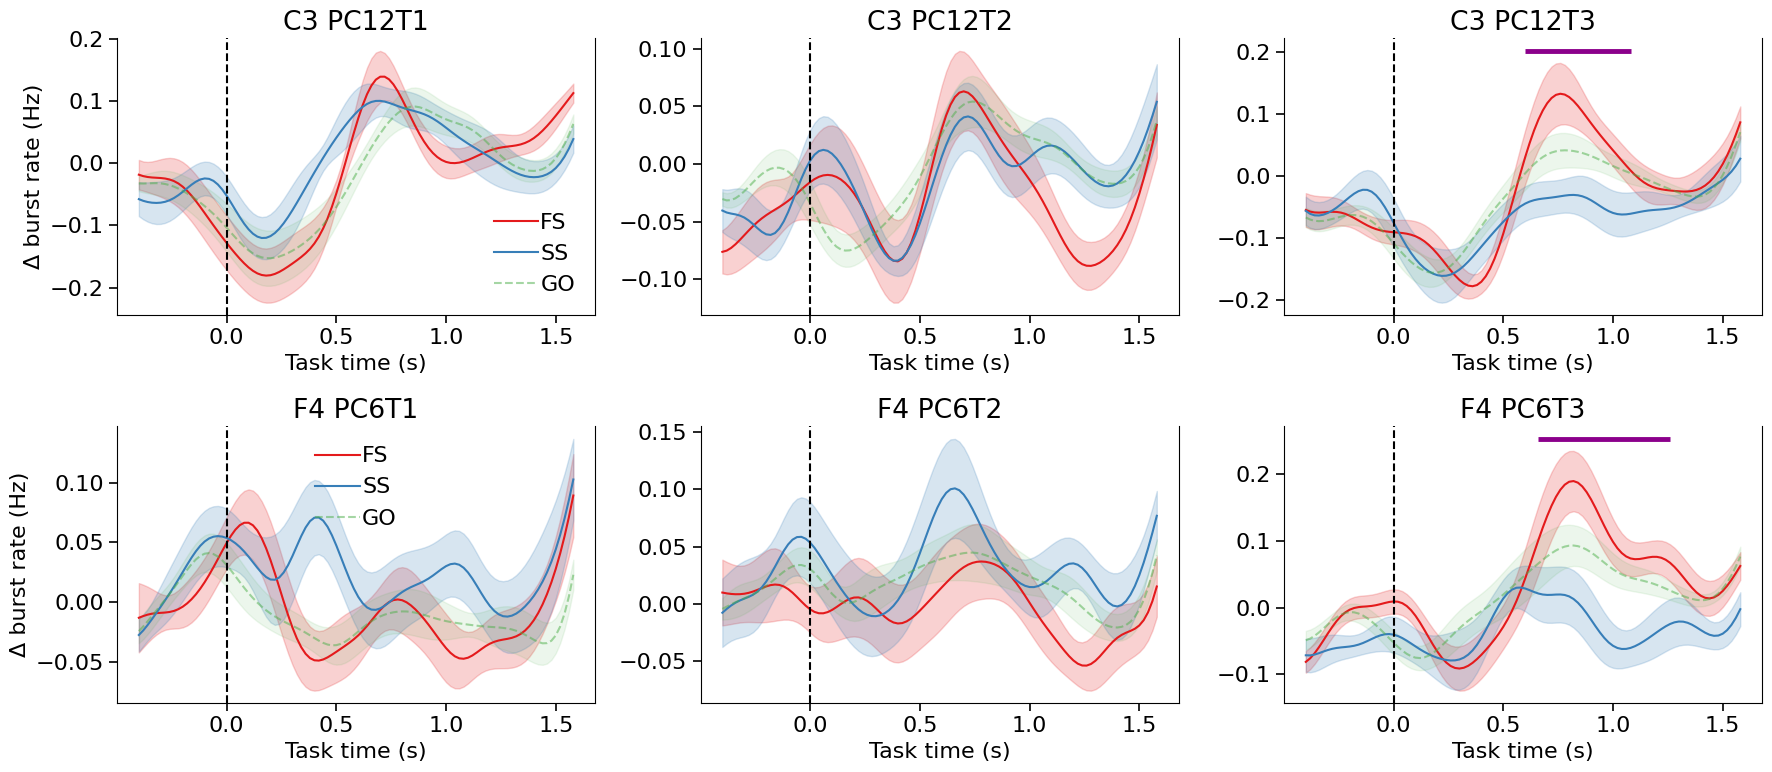

In [19]:
from scipy.stats import t as t_dist
from mne.stats import permutation_cluster_1samp_test

def stat_fun(*args):
    return f_mway_rm(
        np.swapaxes(args, 0, 0),
        factor_levels=[3],
        effects='A',
        return_pvals=False,
    )[0]

def plot_pc_burst_rate(axes, region_name, pc_idx, b_idx):
    n_q = 3
    step = 100 / n_q
    q_bins = np.percentile(all_burst_pc_scores[:, pc_idx], np.arange(0, 100 + step, step))

    time_bin_size = 0.02
    time_bins = np.arange(-1, 2 + time_bin_size, time_bin_size)
    bin_centers = time_bins[:-1]

    bl_map = {'FS': 'FS_bl', 'SS': 'SS_bl', 'GO': 'GO_bl'}

    q_rates_smoothed = {q: {'FS': [], 'SS': [], 'GO': []} for q in range(n_q)}
    subjects = np.unique(all_bursts['subject'])

    cond_colors = {
        'FS': np.array([228, 26, 28]) / 255,
        'SS': np.array([55, 126, 184]) / 255,
        'GO': np.array([77, 175, 74]) / 255,
    }

    for subject in subjects:
        subj_idx = b_idx & (all_bursts['subject'] == subject)
        for q in range(n_q):
            q_idx = ((all_burst_pc_scores[:, pc_idx] >= q_bins[q]) &
                     (all_burst_pc_scores[:, pc_idx] <= q_bins[q + 1]))
            for cond in ['FS', 'SS', 'GO']:
                cond_trials = np.unique(
                    all_bursts['trial'][subj_idx & (all_bursts['condition'] == cond)]
                )
                if len(cond_trials) == 0:
                    continue

                unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & (all_bursts['condition'] == cond) & q_idx],
                    bins=time_bins
                )
                smoothed_rate = gaussian_filter(
                    (unsmoothed_rate / time_bin_size) / len(cond_trials), sigma=5
                )

                bl_cond = bl_map[cond]
                bl_trials = np.unique(
                    all_bursts['trial'][subj_idx & (all_bursts['condition'] == bl_cond)]
                )
                if len(bl_trials) > 0:
                    bl_rate, _ = np.histogram(
                        all_bursts['peak_time'][subj_idx & (all_bursts['condition'] == bl_cond) & q_idx],
                        bins=time_bins
                    )
                    bl_rate = gaussian_filter(
                        (bl_rate / time_bin_size) / len(bl_trials), sigma=5
                    )
                    bl_base_idx = np.where((bin_centers >= -1) & (bin_centers < 0))[0]
                    base_rate = np.mean(bl_rate[bl_base_idx])
                else:
                    print(f"Missing bl for {subject} {cond} Q{q}, falling back to pre-stimulus baseline")
                    base_idx = np.where((bin_centers >= -1) & (bin_centers < 0))[0]
                    base_rate = np.mean(smoothed_rate[base_idx])

                base_rate = np.maximum(base_rate, 1e-6)
                q_rates_smoothed[q][cond].append(smoothed_rate - base_rate)

    # Truncate to display window
    time_bins = time_bins[:-1]
    idx = np.where((time_bins >= -0.4) & (time_bins <= 1.6))[0]
    time_bins = time_bins[idx]

    for q in range(n_q):
        for cond in ['FS', 'SS', 'GO']:
            q_rates_smoothed[q][cond] = np.vstack(q_rates_smoothed[q][cond])[:, idx]

    for q in range(n_q):
        ax = axes[q]

        for cond in ['FS', 'SS', 'GO']:
            mean_rate = np.mean(q_rates_smoothed[q][cond], axis=0)
            sem_rate = np.std(q_rates_smoothed[q][cond], axis=0) / np.sqrt(q_rates_smoothed[q][cond].shape[0])
            alpha = 0.5 if cond == 'GO' else 1.0
            linestyle = '--' if cond == 'GO' else '-'
            ax.plot(time_bins, mean_rate, label=cond, color=cond_colors[cond], alpha=alpha, linestyle=linestyle)
            ax.fill_between(time_bins, mean_rate - sem_rate, mean_rate + sem_rate, alpha=0.2 * alpha, color=cond_colors[cond])

        # Paired t-test on SS vs FS only ? GO excluded from stats
        n_subjects = q_rates_smoothed[q]['SS'].shape[0]
        t_threshold = t_dist.ppf(1 - 0.05, df=n_subjects - 1)
        diff = q_rates_smoothed[q]['SS'] - q_rates_smoothed[q]['FS']
        _, clusters, cluster_p_values, _ = permutation_cluster_1samp_test(
            diff, threshold=t_threshold,
            n_permutations=100000, tail=0, n_jobs=-1, verbose=False
        )

        for c_inds, p_val in zip(clusters, cluster_p_values):
            if p_val < 0.05:
                ax.hlines(
                    ax.get_ylim()[1], time_bins[c_inds[0][0]], time_bins[c_inds[0][-1]],
                    colors='darkmagenta', linewidth=3.5, zorder=5
                )

        ax.axvline(0, color='k', linestyle='--')
        ax.set_title(f'{region_name} PC{pc_idx + 1}T{q + 1}')
        ax.set_xlabel("Task time (s)")
        if q == 0:
            ax.set_ylabel("\u0394 burst rate (Hz)")
            ax.legend()


fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(2, 3, figure=fig)

c3_axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_pc_burst_rate(c3_axes, 'C3', significant_pcs_c3[0], c3_idx)

f4_axes = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])]
plot_pc_burst_rate(f4_axes, 'F4', significant_pcs_f4[1], f4_idx)

plt.tight_layout()
#plt.savefig('./figures/figure_xx_waveform_specific_burst_rate.pdf')

fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(2, 3, figure=fig)

c3_axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
plot_pc_burst_rate(c3_axes, 'C3', significant_pcs_c3[1], c3_idx)

f4_axes = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])]
plot_pc_burst_rate(f4_axes, 'F4', significant_pcs_f4[0], f4_idx)

plt.tight_layout()
plt.savefig('/home/qmoreau/schmidt_data/figures/figure_04_PC_tertile_burst_rate.pdf', bbox_inches='tight')

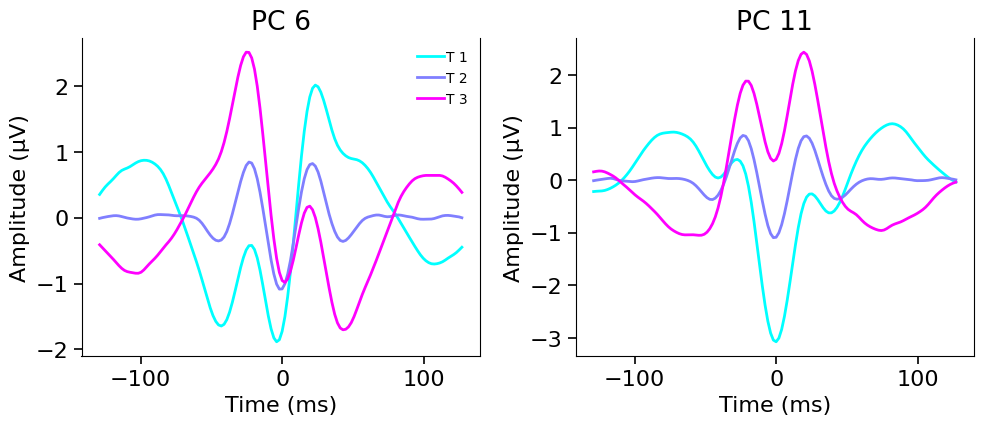

In [20]:
# Quartile calculation
quartiles_laplac_F4 = np.linspace(0, 100, num=4)
quartiles_laplac_F4 = list(zip(quartiles_laplac_F4[:-1], quartiles_laplac_F4[1:]))
col_range_laplac_F4 = plt.cm.cool(np.linspace(0, 1, num=len(quartiles_laplac_F4)))
mean_waveform_laplac_F4 = np.mean(waveforms_laplac_F4, axis=0)

f4_selected_pc = [5, 10]

# Plotting the PCA results
f_laplac_F4=plt.figure(figsize=(20, 20))
ax_idx=0
for pc_ix, pc in enumerate(f4_selected_pc):
    ax_laplac_F4=plt.subplot(5,4,ax_idx+1)
    ax_laplac_F4.set_title(f'PC {pc+1}')  # Set the nice title
    scores_laplac_F4 = pc_scores_laplac_F4[:,pc_ix]  # Select the appropriate principal component from the dataframe
    q_maps_laplac_F4 = []
    for q_ix, (b, e) in enumerate(quartiles_laplac_F4):
        q_map_laplac_F4 = (scores_laplac_F4 > np.percentile(scores_laplac_F4, b)) & (scores_laplac_F4 <= np.percentile(scores_laplac_F4, e))
        q_mean_laplac_F4 = np.mean(waveforms_laplac_F4[q_map_laplac_F4], axis=0)
        ax_laplac_F4.plot(all_bursts['waveform_times'][:132]*1e3, q_mean_laplac_F4*1e3, lw=2, c=col_range_laplac_F4[q_ix], label="T {}".format(q_ix + 1))
#     ax_laplac_F4.plot(all_bursts['waveform_times']*1e3, mean_waveform_laplac_F4*1e3, lw=2, c="black", label="mean")
    if ax_idx==0:
        ax_laplac_F4.legend(fontsize=10)
    ax_laplac_F4.set_xlabel('Time (ms)')
    ax_laplac_F4.set_ylabel('Amplitude (µV)')
    ax_idx=ax_idx+1
plt.tight_layout()
#plt.savefig('./figures/figure_xx_F4_PCA.pdf')

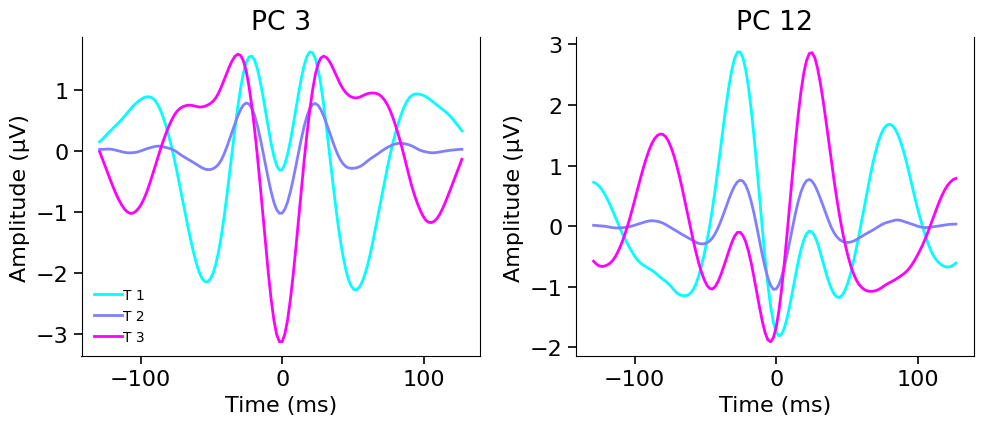

In [21]:
# Quartile calculation
quartiles_laplac_C3 = np.linspace(0, 100, num=4)
quartiles_laplac_C3 = list(zip(quartiles_laplac_C3[:-1], quartiles_laplac_C3[1:]))
col_range_laplac_C3 = plt.cm.cool(np.linspace(0, 1, num=len(quartiles_laplac_C3)))
mean_waveform_laplac_C3 = np.mean(waveforms_laplac_C3, axis=0)

c3_selected_results = [2, 11]
# Plotting the PCA results
f_laplac_C3=plt.figure(figsize=(20, 16))
ax_idx=0
for pc_ix, pc in enumerate(c3_selected_results):
    ax_laplac_C3=plt.subplot(4,4,ax_idx+1)
    ax_laplac_C3.set_title(f'PC {pc+1}')  # Set the nice title
    scores_laplac_C3 = pc_scores_laplac_C3[:,pc_ix]  # Select the appropriate principal component from the dataframe
    q_maps_laplac_C3 = []
    for q_ix, (b, e) in enumerate(quartiles_laplac_C3):
        q_map_laplac_C3 = (scores_laplac_C3 > np.percentile(scores_laplac_C3, b)) & (scores_laplac_C3 <= np.percentile(scores_laplac_C3, e))  # Create a boolean map to select the waveforms_laplac_C3
        q_mean_laplac_C3 = np.mean(waveforms_laplac_C3[q_map_laplac_C3], axis=0)
        ax_laplac_C3.plot(all_bursts['waveform_times'][:132]*1e3, q_mean_laplac_C3*1e3, lw=2, c=col_range_laplac_C3[q_ix], label="T {}".format(q_ix + 1))
    #ax_laplac_C3.plot(all_bursts['waveform_times'][:132]*1e3, mean_waveform_laplac_C3*1e3, lw=2, c="black", label="mean")
    if ax_idx==0:
        ax_laplac_C3.legend(fontsize=10)
    ax_laplac_C3.set_xlabel('Time (ms)')
    ax_laplac_C3.set_ylabel('Amplitude (µV)')
    ax_idx=ax_idx+1
plt.tight_layout()
# plt.savefig('./figures/figure_xx_C3_PCA.pdf')

/tmp/ipykernel_57726/920279480.py:90: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  _, clusters, cluster_p_values, _ = spatio_temporal_cluster_test(


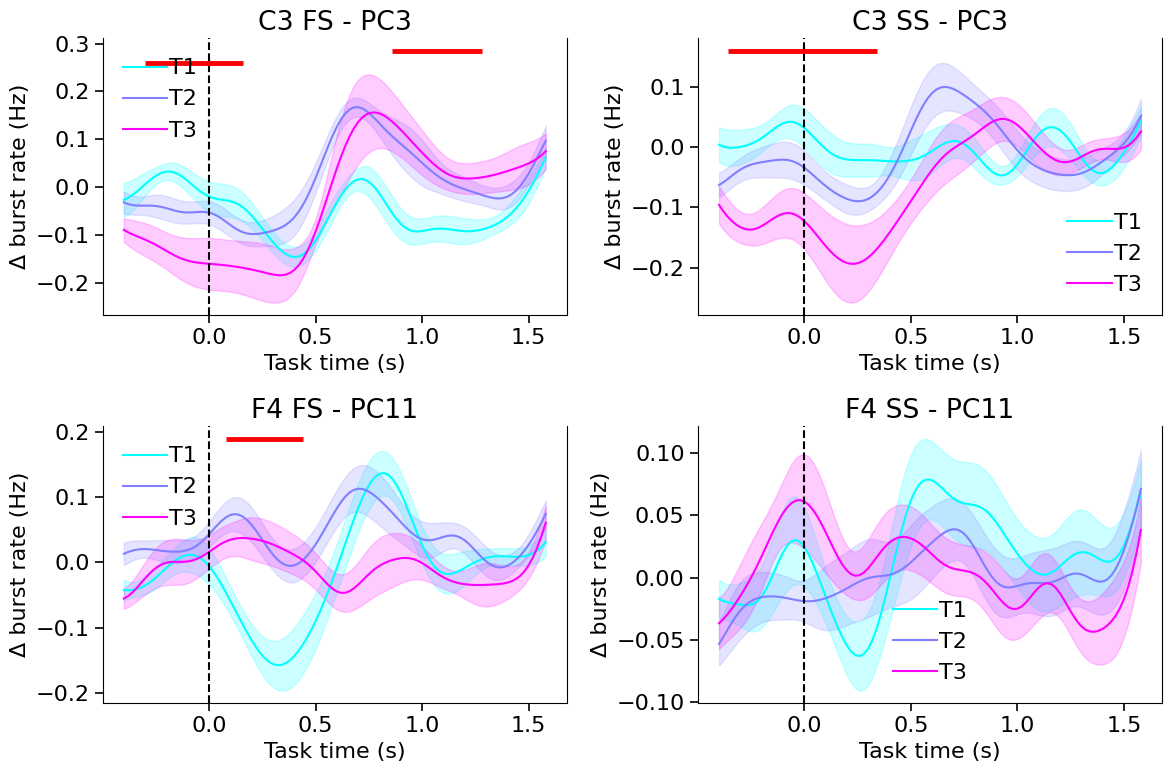

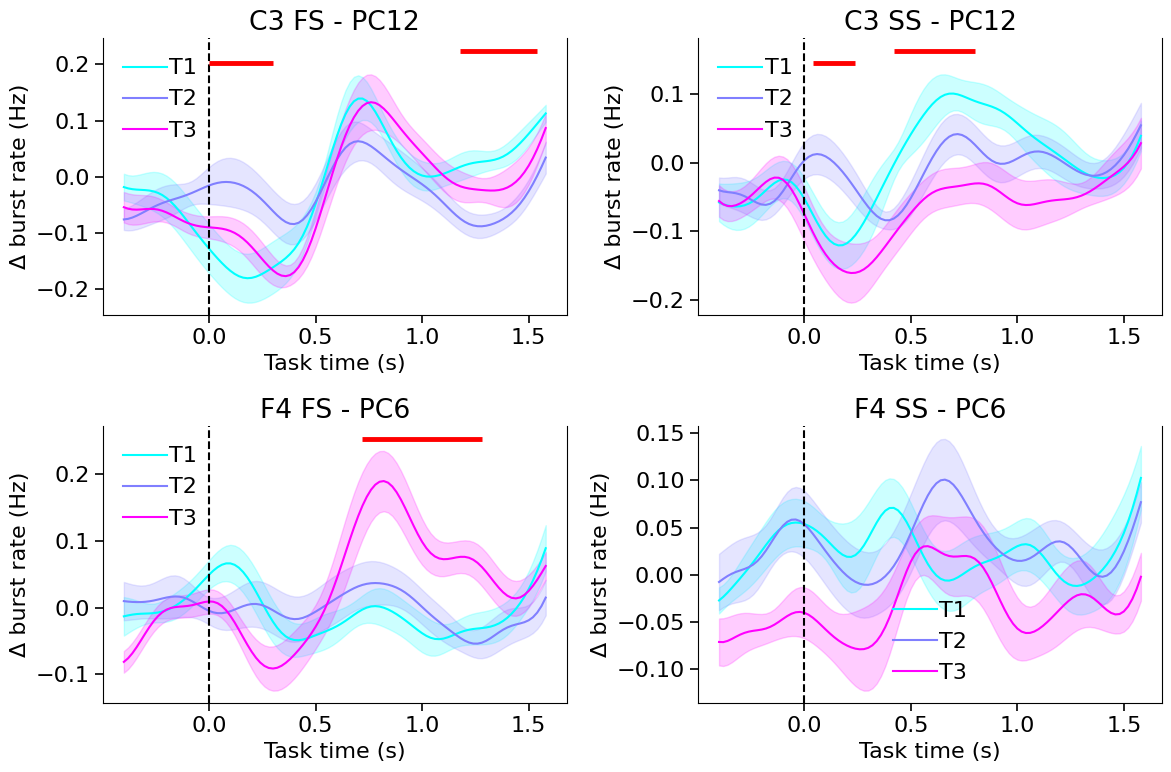

In [22]:
from scipy.stats import t as t_dist
from mne.stats import permutation_cluster_1samp_test

def stat_fun(*args):
    return f_mway_rm(
        np.swapaxes(args, 0, 0),
        factor_levels=[3],
        effects='A',
        return_pvals=False,
    )[0]

def plot_pc_burst_rate(axes, region_name, pc_idx, b_idx):
    n_q = 3
    step = 100 / n_q
    q_bins = np.percentile(all_burst_pc_scores[:, pc_idx], np.arange(0, 100 + step, step))

    time_bin_size = 0.02
    time_bins = np.arange(-1, 2 + time_bin_size, time_bin_size)
    bin_centers = time_bins[:-1]

    bl_map = {'FS': 'FS_bl', 'SS': 'SS_bl'}

    q_rates_smoothed = {cond: {q: [] for q in range(n_q)} for cond in ['FS', 'SS']}
    subjects = np.unique(all_bursts['subject'])

    tertile_colors = plt.cm.cool(np.linspace(0, 1, n_q))

    for subject in subjects:
        subj_idx = b_idx & (all_bursts['subject'] == subject)
        for q in range(n_q):
            q_idx = ((all_burst_pc_scores[:, pc_idx] >= q_bins[q]) &
                     (all_burst_pc_scores[:, pc_idx] <= q_bins[q + 1]))
            for cond in ['FS', 'SS']:
                cond_trials = np.unique(
                    all_bursts['trial'][subj_idx & (all_bursts['condition'] == cond)]
                )
                if len(cond_trials) == 0:
                    continue

                unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & (all_bursts['condition'] == cond) & q_idx],
                    bins=time_bins
                )
                smoothed_rate = gaussian_filter(
                    (unsmoothed_rate / time_bin_size) / len(cond_trials), sigma=5
                )

                bl_cond = bl_map[cond]
                bl_trials = np.unique(
                    all_bursts['trial'][subj_idx & (all_bursts['condition'] == bl_cond)]
                )
                if len(bl_trials) > 0:
                    bl_rate, _ = np.histogram(
                        all_bursts['peak_time'][subj_idx & (all_bursts['condition'] == bl_cond) & q_idx],
                        bins=time_bins
                    )
                    bl_rate = gaussian_filter(
                        (bl_rate / time_bin_size) / len(bl_trials), sigma=5
                    )
                    bl_base_idx = np.where((bin_centers >= -1) & (bin_centers < 0))[0]
                    base_rate = np.mean(bl_rate[bl_base_idx])
                else:
                    print(f"Missing bl for {subject} {cond} Q{q}, falling back to pre-stimulus baseline")
                    base_idx = np.where((bin_centers >= -1) & (bin_centers < 0))[0]
                    base_rate = np.mean(smoothed_rate[base_idx])

                base_rate = np.maximum(base_rate, 1e-6)
                q_rates_smoothed[cond][q].append(smoothed_rate - base_rate)

    # Truncate to display window
    time_bins = time_bins[:-1]
    idx = np.where((time_bins >= -0.4) & (time_bins <= 1.6))[0]
    time_bins = time_bins[idx]

    for cond in ['FS', 'SS']:
        for q in range(n_q):
            q_rates_smoothed[cond][q] = np.vstack(q_rates_smoothed[cond][q])[:, idx]

    for ax, cond in zip(axes, ['FS', 'SS']):
        for q in range(n_q):
            mean_rate = np.mean(q_rates_smoothed[cond][q], axis=0)
            sem_rate = np.std(q_rates_smoothed[cond][q], axis=0) / np.sqrt(q_rates_smoothed[cond][q].shape[0])
            ax.plot(time_bins, mean_rate, label=f'T{q+1}', color=tertile_colors[q])
            ax.fill_between(time_bins, mean_rate - sem_rate, mean_rate + sem_rate,
                            alpha=0.2, color=tertile_colors[q])

        # 3-level RM ANOVA across tertiles
        X = np.stack([q_rates_smoothed[cond][q] for q in range(n_q)], axis=1)
        threshold = f_threshold_mway_rm(n_subjects=X.shape[0], factor_levels=[3], effects='A')
        _, clusters, cluster_p_values, _ = spatio_temporal_cluster_test(
            X, threshold=threshold, stat_fun=stat_fun,
            n_permutations=10000, tail=1.0, n_jobs=-1, verbose=False
        )
        for (c_inds,), p_val in zip(clusters, cluster_p_values):
            if p_val < 0.05:
                ax.hlines(
                    ax.get_ylim()[1], time_bins[c_inds[0]], time_bins[c_inds[-1]],
                    colors='red', linewidth=3.5, zorder=5
                )

        ax.axvline(0, color='k', linestyle='--')
        ax.set_title(f'{region_name} {cond} - PC{pc_idx + 1}')
        ax.set_xlabel("Task time (s)")
        ax.set_ylabel("\u0394 burst rate (Hz)")
        ax.legend()


fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

c3_axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
plot_pc_burst_rate(c3_axes, 'C3', significant_pcs_c3[0], c3_idx)

f4_axes = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
plot_pc_burst_rate(f4_axes, 'F4', significant_pcs_f4[1], f4_idx)

plt.tight_layout()

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

c3_axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
plot_pc_burst_rate(c3_axes, 'C3', significant_pcs_c3[1], c3_idx)

f4_axes = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
plot_pc_burst_rate(f4_axes, 'F4', significant_pcs_f4[0], f4_idx)

plt.tight_layout()
# plt.savefig('/home/qmoreau/stop_go_bursts/figures/figure_04_PC_tertile_burst_rate.pdf', bbox_inches='tight')

In [23]:
print('C3 significant PCs:', significant_pcs_c3)
print('F4 significant PCs:', significant_pcs_f4)

C3 significant PCs: [2, 11]
F4 significant PCs: [5, 10]
